# <span style="color:green"> Numerical Simulation Laboratory (NSL) </span>
## <span style="color:blue">  Numerical exercises 2</span>


### Exercise 02.1
- Compute the following 1D integral via Monte Carlo 
$$I = \int_0^1 \frac{\pi}{2}\cos(\pi x/2) dx = 1$$

1. sampling a uniform distribution in $[0,1]$
2. using importance sampling (i.e. sampling a non-uniform probability in $[0,1]$)

<span style="color:red">Show a picture of both your estimations of $I$</span> and their uncertainties with a large number of *throws* $M$ (e.g. $M\ge 10^4$) as a function of the number of blocks, $N$</font>.

## Stima integrali con Monte Carlo

La stima di un integrale mediante metodi Montecarlo si articola nei seguenti passaggi:

- Fattorizzare l'integranda in modo tale che l'integrale possa essere scritto come
  $$I = \int_{\Omega} g(x)p(x)dx \quad \text{dove} \quad p(x) \ge 0 \ \forall x \in \Omega; \ \int_{\Omega} p(x)dx = 1$$
- Va scelta $p(x)$ in modo intelligente (**importance sampling**) in modo da ridurre i tempi di calcolo
- Viene calcolato l'integrale come
  $$G_N = \frac{1}{N} \sum_{i=1}^{N} g(x_i)$$ con $$\sigma_I^2 = \int_{\Omega} g^2(x)p(x)dx - I^2 \qquad$$ e incertezza $$\text{errore} = \varepsilon = \frac{\sigma_I}{\sqrt{N}}$$

## Importance sampling

Dato l'integrale precendete che si desidera calcolare:
$$I = \int_{\Omega} g(\vec{x})p(\vec{x})d\vec{x}$$

Se la distribuzione di probabilità originaria $p(\vec{x})$ non è buona per il campionamento (per esempio potrebbe campionare tanti punti in regioni in cui $g(x)$ è circa nulla), è possibile introdurre una **nuova densità di probabilità** $d(\vec{x})$ per riscrivere l'integrale:
$$I = \int_{\Omega} \left[ \frac{g(\vec{x})p(\vec{x})}{d(\vec{x})} \right] d(\vec{x})d\vec{x}$$

Con le proprietà:
$$d(\vec{x}) \ge 0 \quad \forall \vec{x} \in \Omega, \qquad \int_{\Omega} d(\vec{x})d\vec{x} = 1$$

L'algoritmo Monte Carlo valuterà l'integrale campionando i punti $\vec{x}_i$ dalla nuova distribuzione $d(\vec{x})$ e calcolando nuova media:
$$G_N = \frac{1}{N} \sum_{i=1}^{N} \frac{g(\vec{x}_i)p(\vec{x}_i)}{d(\vec{x}_i)}$$

La nuova varianza assume la forma:
$$\text{var}[I]_d = \int_{\Omega} \left[ \frac{g(\vec{x})p(\vec{x})}{d(\vec{x})} \right]^2 d(\vec{x})d\vec{x} - I^2$$

Dunque l'obiettivo dell'importance sampling consiste nello scegliere una $d(\vec{x})$ che minimizzi il termine $\mathbb{E}[(gp/d)^2]$.

La **distribuzione ottimale** risulta:
$$d(\vec{x}) = \frac{g(\vec{x})p(\vec{x})}{I}$$


Tuttavia, è bene ricordare che l'obiattivo è calcolare il valore dell'integrale $I$, che dunque non è noto a priori. Quindi dal punto di vista operativo l'approccio è quello di scegliere simili a $g(\vec{x})p(\vec{x})$ in modo tale da ridurre la varianza rispetto a un campionamento uniforme.

## Esercizio importance sampling

In questo caso $f(x ) = \frac{\pi}{2}\cos(\pi x/2)$ e voglio calcolare l'integrale nell'intervallo $[0, 1]$

Espando dunque in serie di Taylor $f(x)$ centrata nel punto $x_0 = 1$.

$$f(x) = f(1) + f'(1)(x-1) + \frac{f''(1)}{2}(x-1)^2 + \dots$$

Arresto lo sviluppo al primo termine.
$$f(x) \approx \frac{\pi^2}{4}(-x + 1)$$

Calcolo la normalizzazione dell'integrale nello stesso intervallo della funzione approssimata:
$$\int_{0}^{1} \left[ -\frac{\pi^2}{4}x + \frac{\pi^2}{4} \right] dx = \frac{\pi^2}{8}$$

Ottengo dunque una distribuzione di probabilità normalizzata
$$p(x) = -2x + 2$$

$\int f(x)dx = \int g(x)p(x)dx$. Dunque $g(x) = \frac{f(x)}{p(x)}$.


$$\implies g(x)  = \frac{\pi}{4}\frac{\cos\left(\frac{\pi x}{2}\right)}{-x + 1}$$


Per poter estrarre numeri che seguono la distribuzione $p(x) = -2x + 2$, utilizzo il metodo della trasformata inversa calcolando la cumulativa $F_x(x)$:

$$F_x(x) = \int_{0}^{x} p(x') dx' = -x^2 + 2x$$

Pongo la cumulativa uguale a una variabile casuale $y$ estratta uniformemente nell'intervallo $[0, 1]$ e risolvo rispetto a $x$:
$$x = 1 - \sqrt{1 - y}$$


Ho preso il ramo negativo perchè il ramo positivo genererebbe valori $> 1$ esterni al dominio di integrazione

Possiamo chiaramente notare dal grafico sottostante che mediante l'importance sampling il grafico vada a convergere al valore vero molto più velocemente. Queste simulazioni sono caratterizzate da $M = 10000$ simulazioni totali da $N = 100$ blocchi.


In [1]:
import matplotlib.pyplot as plt
import numpy as np

data1 = np.loadtxt('integrale.dat')
data2 = np.loadtxt('integrale2.dat')

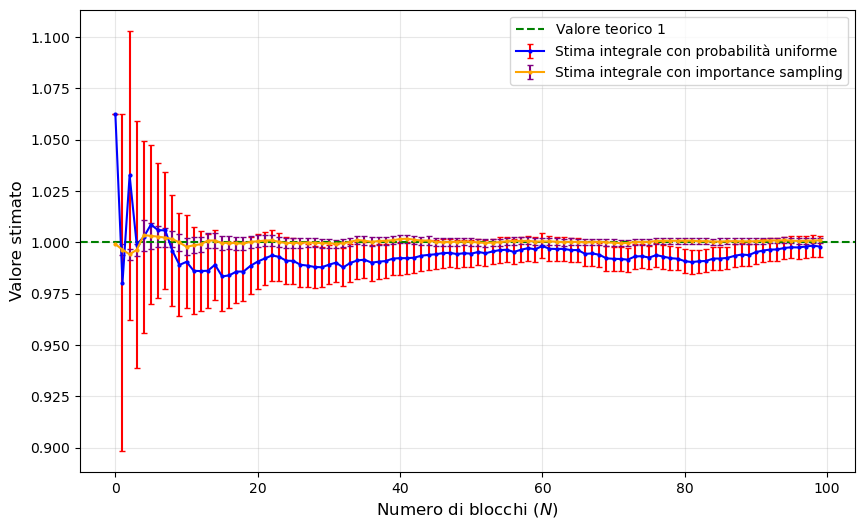

In [2]:
x = data1[:, 0]     
y = data1[:, 1]  
y_err = data1[:, 2]  

x2 = data2[:, 0]      
y2 = data2[:, 1]    
y2_err = data2[:, 2]  

plt.figure(figsize=(10, 6))
plt.errorbar(x, y, yerr=y_err, color='blue', ecolor='red', label='Stima integrale con probabilità uniforme', capsize=2, fmt='-o', markersize=2)
plt.errorbar(x2, y2, yerr=y2_err, color='orange', ecolor='purple', label='Stima integrale con importance sampling', capsize=2, fmt='-o', markersize=2)
plt.axhline(y=1, color='green', linestyle='--', label='Valore teorico $1$')
plt.xlabel('Numero di blocchi ($N$)', fontsize=12)
plt.ylabel('Valore stimato', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

### Exercise 02.2
- <span style="color:red">3D Random Walks (RW) on a cubic lattice and in the continuum:</span> Repeat many times (e.g. say $10^4$) the simulation of a random walk in 3D always starting at the origin

1. on a cubic lattice with lattice constant $a=1$; at each discrete time the walker makes a forward or backward step of length equal to $a$ in one of the 3 principal directions of the lattice: $x$, $y$ or $z$
2. in the continuum; at each discrete time the walker makes a step of length equal to $a(=1)$ along a **random direction** obtained by sampling **uniformly** the solid angle: $\theta \in [0,\pi]$ and $\phi \in [0,2\pi]$

<span style="color:red">Show a picture of $\sqrt{\langle |\vec{r}_N|^2 \rangle_{RW}}$ for both RWs</span>, with their statistical uncertainties, as function of the step $i\in [0,10^2]$.

Suggestion: divide your $M$ throws into a reasonable number of blocks, compute $\sqrt{\langle |\vec{r}_N|^2 \rangle_{RW}}$ as function of the step $i\in [0,10^2]$ in each block and use these values (for fixed $i$) to obtain the average value and its statistical uncertainty.

Note that you could try to fit both results with a function like $f(N)=k\sqrt{N}$. Do your results indicate a diffusive behavior?

I parametri della simulazione sono i seguenti:
- Numero totale di traiettorie generate $M = 10000$.
- $N = 100$ blocchi indipendenti.
- $L = M/N = 100$ traiettorie per ogni blocco.
- Numero di passi temporali eseguiti per cammino $t_{\text{max}} =100$.


Per ciascun blocco $i$, avvio la generazione delle $L$ traiettorie. A ogni passo temporale $t$, la posizione corrente del camminatore viene aggiornata nei seguenti modi:
1. RW nel reticolo: Estraggo uniformemente una direzione fra i 6 versori delle coordinate (+ e - in ogni direzione) $\pm \hat{x}, \pm \hat{y}, \pm \hat{z}$.
2. RW nel continuo: Campiono isotropicamente l'angolo solido estraendo $\phi$ in modo uniforme tra $[0, 2\pi]$ e un angolo polare tramite il campionamento uniforme del coseno $\cos(\theta)$ in $[-1, 1]$.

Al termine di ogni traiettoria all'interno del blocco, la distanza dall'origine $r^2(t) = x^2(t) + y^2(t) + z^2(t)$. Una volta completato il singolo blocco, viene estratta la radice quadrata della media di blocco:

$$\text{misura}(t = t^*) = \sqrt{\frac{1}{L} \sum_{j=1}^{L} r^2_{j}(t^*)}$$


I dati salvati sono stati plottati in funzione del tempo sovrapponendo i punti numerici al fit teorico ideale della forma $f(N) = k\sqrt{N}$.

Risultato del fit: k = 1.0024 +/- 0.0002
Valore teorico atteso per passo unitario (a=1): k = 1.0


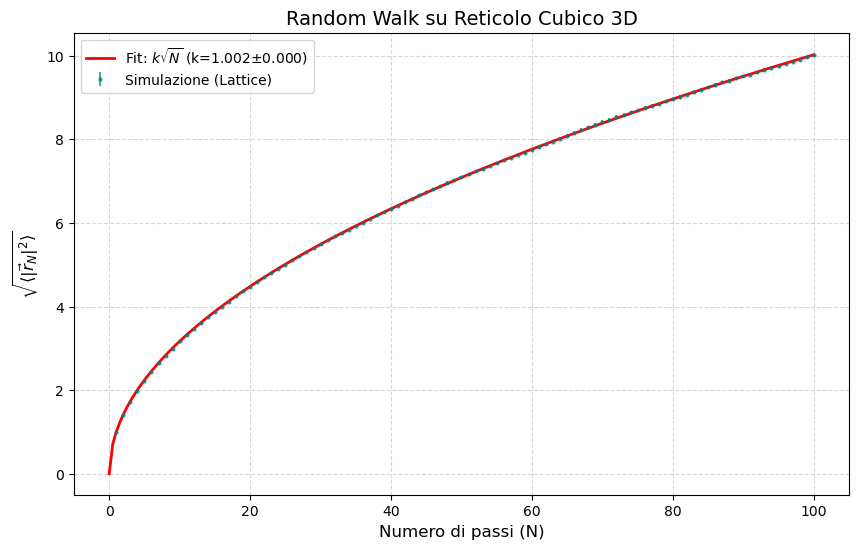

In [3]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

data = np.loadtxt('RW_lattice.dat')
t = data[:, 0]
r_ave = data[:, 1]
error = data[:, 2]

def fit_func(N, k):
    return k * np.sqrt(N)

popt, pcov = curve_fit(fit_func, t, r_ave)
k_best = popt[0]
k_error = np.sqrt(pcov[0, 0])

plt.figure(figsize=(10, 6))
plt.errorbar(t, r_ave, yerr=error, fmt='o', markersize=2, label='Simulazione (Lattice)', color='teal', alpha=0.7)
t_fit = np.linspace(0, 100, 200)
plt.plot(t_fit, fit_func(t_fit, k_best), color='red', label=f'Fit: $k\\sqrt{{N}}$ (k={k_best:.3f}±{k_error:.3f})', linewidth=2)
plt.title('Random Walk su Reticolo Cubico 3D', fontsize=14)
plt.xlabel('Numero di passi (N)', fontsize=12)
plt.ylabel('$\\sqrt{\\langle |\\vec{r}_N|^2 \\rangle}$', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
print(f"Risultato del fit: k = {k_best:.4f} +/- {k_error:.4f}")
print(f"Valore teorico atteso per passo unitario (a=1): k = 1.0")
plt.show()


<span style="color:red"> **Non richiesto**.</span> Ero curioso di vedere il percorso di un walker

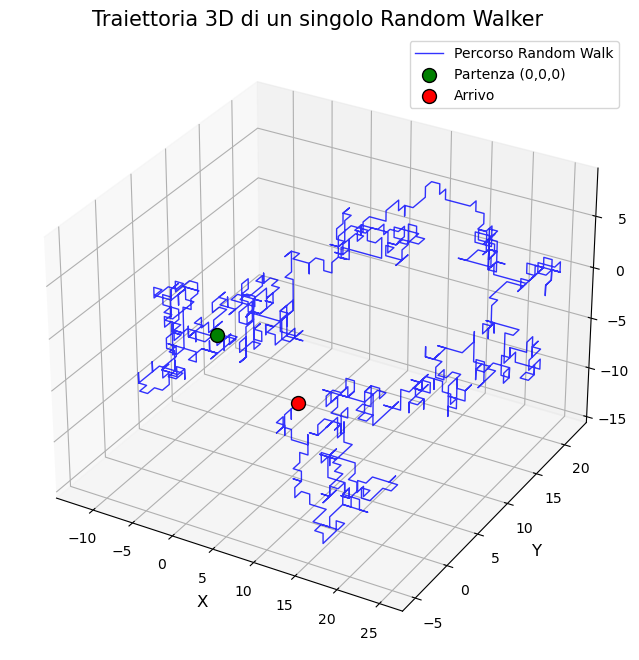

In [4]:
import matplotlib.pyplot as plt
import numpy as np

path = np.loadtxt('single_walker.dat')
x, y, z = path[:, 0], path[:, 1], path[:, 2]

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.plot(x, y, z, lw=1, alpha=0.8, color='blue', label='Percorso Random Walk')
ax.scatter(x[0], y[0], z[0], color='green', s=100, label='Partenza (0,0,0)', edgecolors='black')
ax.scatter(x[-1], y[-1], z[-1], color='red', s=100, label='Arrivo', edgecolors='black')
ax.set_title('Traiettoria 3D di un singolo Random Walker', fontsize=15)
ax.set_xlabel('X', fontsize=12)
ax.set_ylabel('Y', fontsize=12)
ax.set_zlabel('Z', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.3)
ax.legend()
plt.show()

Risultato del fit: k = 0.99053 +/- 0.00024
Valore teorico atteso per passo unitario (a=1): k = 1.0


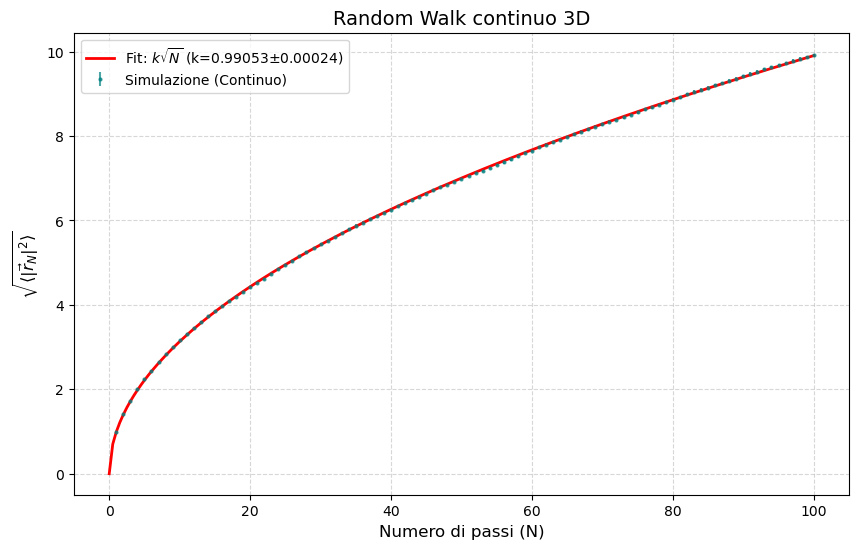

In [5]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

# 1. Caricamento dati
# Il file deve avere 3 colonne: Passo (t), Media r, Errore
data = np.loadtxt('RW_continuum.dat')
t = data[:, 0]
r_ave = data[:, 1]
error = data[:, 2]

# 2. Definizione funzione di fit: f(N) = k * sqrt(N)
def fit_func(N, k):
    return k * np.sqrt(N)

# Esecuzione del fit
popt, pcov = curve_fit(fit_func, t, r_ave)
k_best = popt[0]
k_error = np.sqrt(pcov[0, 0])

# 3. Plot dei risultati
plt.figure(figsize=(10, 6))

# Dati sperimentali con barre d'errore
plt.errorbar(t, r_ave, yerr=error, fmt='o', markersize=2, label='Simulazione (Continuo)', color='teal', alpha=0.7)

# Curva di fit
t_fit = np.linspace(0, 100, 200)
plt.plot(t_fit, fit_func(t_fit, k_best), color='red', label=f'Fit: $k\\sqrt{{N}}$ (k={k_best:.5f}±{k_error:.5f})', linewidth=2)

# Formattazione grafico
plt.title('Random Walk continuo 3D', fontsize=14)
plt.xlabel('Numero di passi (N)', fontsize=12)
plt.ylabel('$\\sqrt{\\langle |\\vec{r}_N|^2 \\rangle}$', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

# 4. Commento sui risultati
print(f"Risultato del fit: k = {k_best:.5f} +/- {k_error:.5f}")
print(f"Valore teorico atteso per passo unitario (a=1): k = 1.0")

plt.show()


<span style="color:red"> **Non richiesto**.</span> Ero curioso di vedere il percorso di un walker

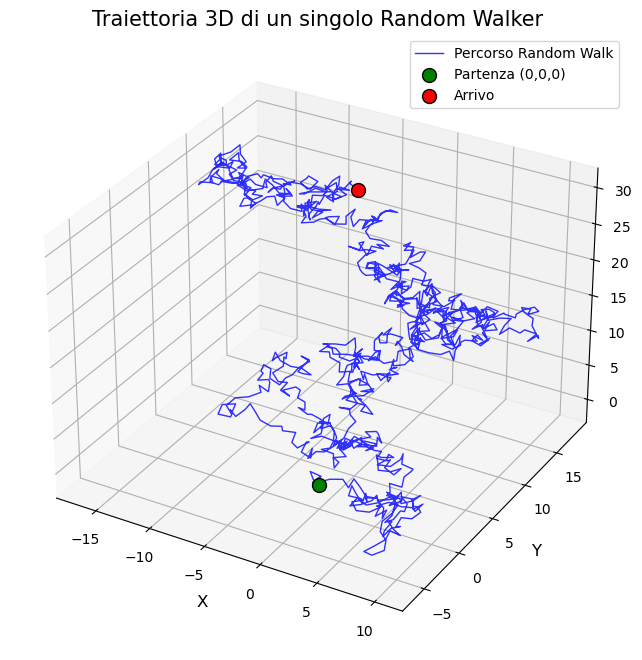

In [6]:
import matplotlib.pyplot as plt
import numpy as np

path = np.loadtxt('single_walker_continuum.dat')
x, y, z = path[:, 0], path[:, 1], path[:, 2]

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.plot(x, y, z, lw=1, alpha=0.8, color='blue', label='Percorso Random Walk')
ax.scatter(x[0], y[0], z[0], color='green', s=100, label='Partenza (0,0,0)', edgecolors='black')
ax.scatter(x[-1], y[-1], z[-1], color='red', s=100, label='Arrivo', edgecolors='black')
ax.set_title('Traiettoria 3D di un singolo Random Walker', fontsize=15)
ax.set_xlabel('X', fontsize=12)
ax.set_ylabel('Y', fontsize=12)
ax.set_zlabel('Z', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.3)
ax.legend()
plt.show()

Possiamo notare in entrambe i casi come i dati mostrino un comportamento diffusivo. Infatti la varianza di una Random Walk, affinche mostri un comportamento diffusivo deve soddisfare la relazione $\sigma^2 = N \cdot a^2$, ovvero $\sigma = \sqrt{N} \, a$. Poichè il passo della RW è $a = 1$,
il fit con una funzione del tipo $k\,\sqrt{N}$ deve restituire un parametro $k$ prossimo a 1 ed è proprio quello che possiamo osservare dai due fit precendenti.